In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_test = pd.read_excel("DataWeb-Query-Export-20year-HTS2.xlsx", sheet_name="Customs Value", nrows=5)
print(df_test.head())

       Data Type  HTS Number  \
0  Customs Value           1   
1  Customs Value           2   
2  Customs Value           3   
3  Customs Value           4   
4  Customs Value           5   

                                         Description       2004        2005  \
0                                       LIVE ANIMALS   13614537    23618823   
1                         MEAT AND EDIBLE MEAT OFFAL    7985326    10175633   
2  FISH AND CRUSTACEANS, MOLLUSCS AND OTHER AQUAT...  956502728  1086664381   
3  DAIRY PRODUCE; BIRDS' EGGS; NATURAL HONEY; EDI...   35423153    27352351   
4                   PRODUCTS OF ANIMAL ORIGIN, NESOI  269469285   278531812   

         2006        2007        2008        2009        2010  ...  \
0    28997901    34509309    41772784    30266741    31787523  ...   
1    12261665    17432997    15593652    18881206    21220808  ...   
2  1421534255  1540069157  1695620542  1562019130  1809591082  ...   
3    31589431    15656769    15637028     7063441   

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [7]:
df = pd.read_excel("DataWeb-Query-Export-20year-HTS2.xlsx", sheet_name="Customs Value")

years = [str(y) for y in range(2004, 2025)]

df_clean = df.dropna(subset=["HTS Number", "Description"]).copy()
for y in years:
    df_clean[y] = pd.to_numeric(df_clean[y], errors="coerce")

necessities = [9,16,17,18,19,20,21,22,33,34,42,61,62,64,96]
home_goods = [39,44,63,69,70,82,94,95]
electronics = [84,85,86,87,88,89,90,91]

df_nec = df_clean[df_clean["HTS Number"].isin(necessities)][years].sum()
df_home = df_clean[df_clean["HTS Number"].isin(home_goods)][years].sum()
df_ele = df_clean[df_clean["HTS Number"].isin(electronics)][years].sum()
df_total = df_nec + df_home + df_ele

x = [int(y) for y in years]
y_nec = df_nec.values
y_home = df_home.values
y_ele = df_ele.values
y_total = df_total.values

print("Data loading and cleaning completed")
print(f"year: {x}")

Data loading and cleaning completed
year: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


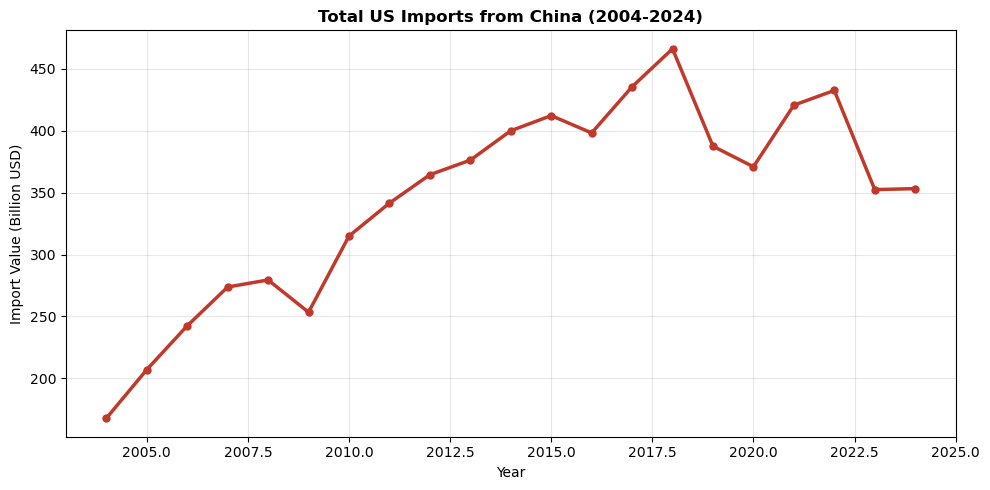

Total imports grew strongly over 20 years. A short-term drop appeared in 2019–2020, but the overall trend remained stable and upward.


In [8]:
plt.figure(figsize=(10,5))
plt.plot(x, y_total/1e9, color="#c0392b", linewidth=2.5, marker="o", markersize=5)
plt.title("Total US Imports from China (2004-2024)", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Import Value (Billion USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Total imports grew strongly over 20 years. A short-term drop appeared in 2019–2020, but the overall trend remained stable and upward.")

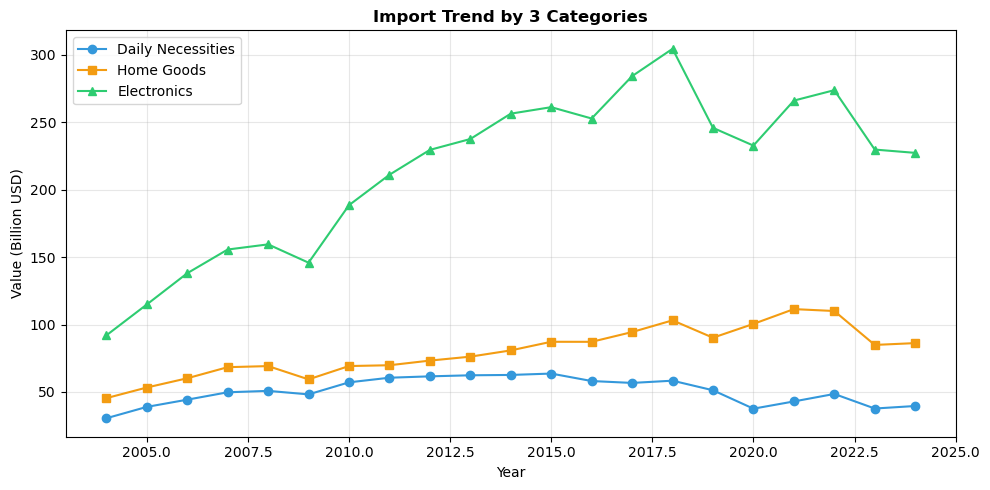

Electronics has always been the largest import category and grew the fastest. Daily necessities and home goods grew steadily but at a much lower rate, and the gap between electronics and the other two categories widened over time.


In [9]:
plt.figure(figsize=(10,5))
plt.plot(x, y_nec/1e9, label="Daily Necessities", color="#3498db", marker="o")
plt.plot(x, y_home/1e9, label="Home Goods", color="#f39c12", marker="s")
plt.plot(x, y_ele/1e9, label="Electronics", color="#2ecc71", marker="^")
plt.title("Import Trend by 3 Categories", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Value (Billion USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Electronics has always been the largest import category and grew the fastest. Daily necessities and home goods grew steadily but at a much lower rate, and the gap between electronics and the other two categories widened over time.")

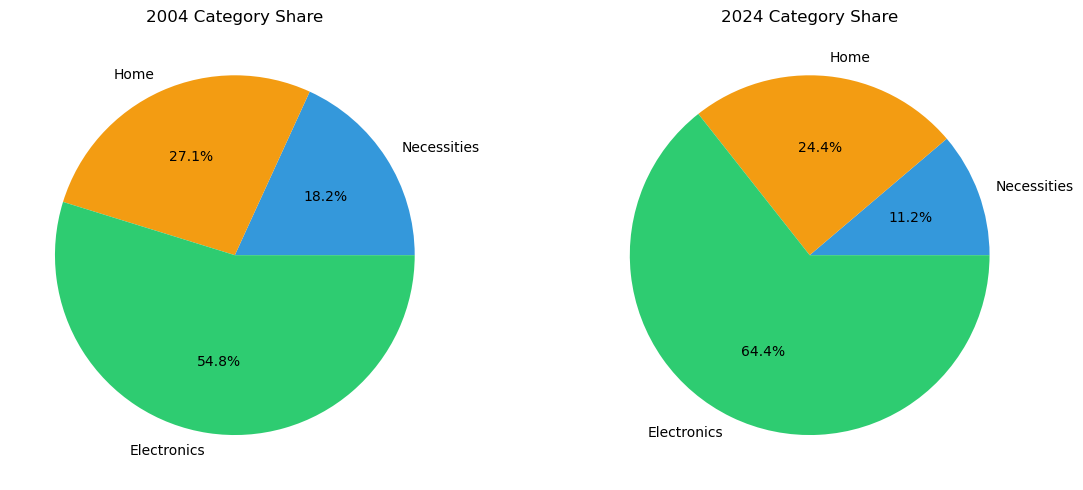

The share of electronics increased significantly from 2004 to 2024, while the proportion of daily necessities decreased. The import structure shifted from daily necessities‑oriented to electronics‑dominated.


In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
values2004 = [y_nec[0], y_home[0], y_ele[0]]
plt.pie(values2004, labels=["Necessities","Home","Electronics"], 
        autopct="%1.1f%%", colors=["#3498db","#f39c12","#2ecc71"])
plt.title("2004 Category Share")

plt.subplot(1,2,2)
values2024 = [y_nec[-1], y_home[-1], y_ele[-1]]
plt.pie(values2024, labels=["Necessities","Home","Electronics"], 
        autopct="%1.1f%%", colors=["#3498db","#f39c12","#2ecc71"])
plt.title("2024 Category Share")

plt.tight_layout()
plt.show()

print("The share of electronics increased significantly from 2004 to 2024, while the proportion of daily necessities decreased. The import structure shifted from daily necessities‑oriented to electronics‑dominated.")

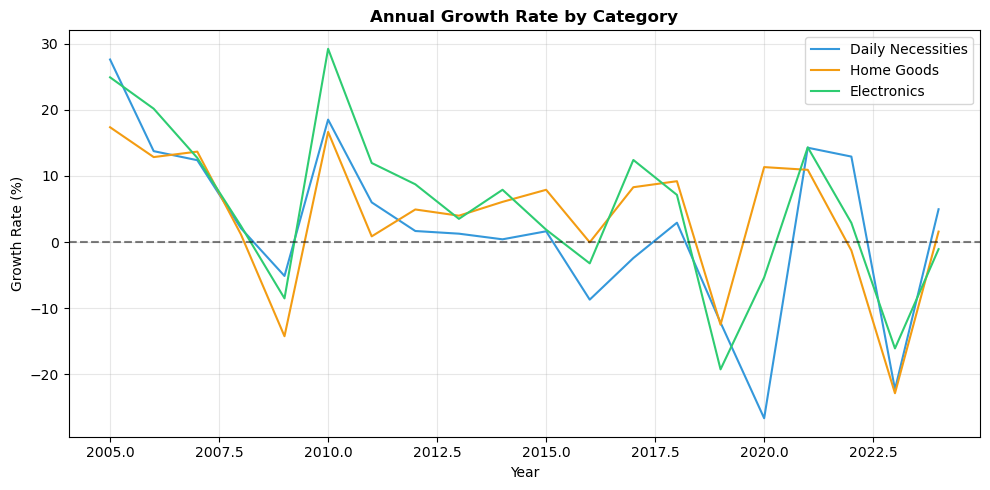

All three categories showed similar growth fluctuations. Home goods had larger volatility, while daily necessities were more stable.


In [11]:
gr_nec = pd.Series(y_nec).pct_change() * 100
gr_home = pd.Series(y_home).pct_change() * 100
gr_ele = pd.Series(y_ele).pct_change() * 100

plt.figure(figsize=(10,5))
plt.plot(x[1:], gr_nec[1:], label="Daily Necessities", color="#3498db")
plt.plot(x[1:], gr_home[1:], label="Home Goods", color="#f39c12")
plt.plot(x[1:], gr_ele[1:], label="Electronics", color="#2ecc71")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Annual Growth Rate by Category", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("All three categories showed similar growth fluctuations. Home goods had larger volatility, while daily necessities were more stable.")

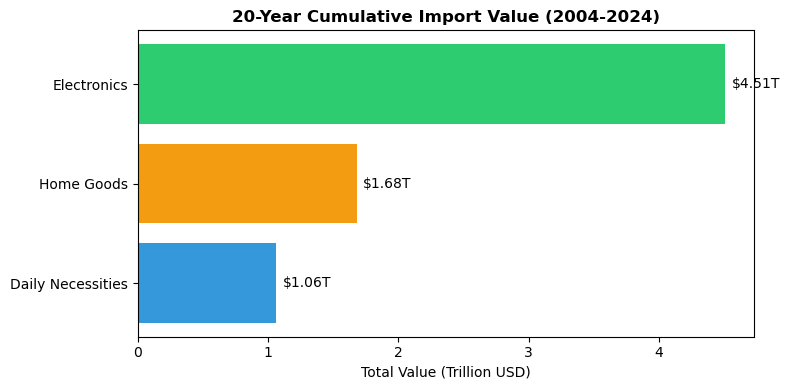

Over the 20‑year period, electronics had the largest cumulative import value, exceeding the sum of daily necessities and home goods. It has been the backbone of US imports from China.


In [12]:
labels = ["Daily Necessities", "Home Goods", "Electronics"]
cumulative = [y_nec.sum(), y_home.sum(), y_ele.sum()]
cumulative_trillion = [v / 1e12 for v in cumulative]

plt.figure(figsize=(8,4))
bars = plt.barh(labels, cumulative_trillion, color=["#3498db","#f39c12","#2ecc71"])
plt.title("20-Year Cumulative Import Value (2004-2024)", fontweight="bold")
plt.xlabel("Total Value (Trillion USD)")

for bar, val in zip(bars, cumulative_trillion):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2, f"${val:.2f}T", va="center")

plt.tight_layout()
plt.show()

print("Over the 20‑year period, electronics had the largest cumulative import value, exceeding the sum of daily necessities and home goods. It has been the backbone of US imports from China.")


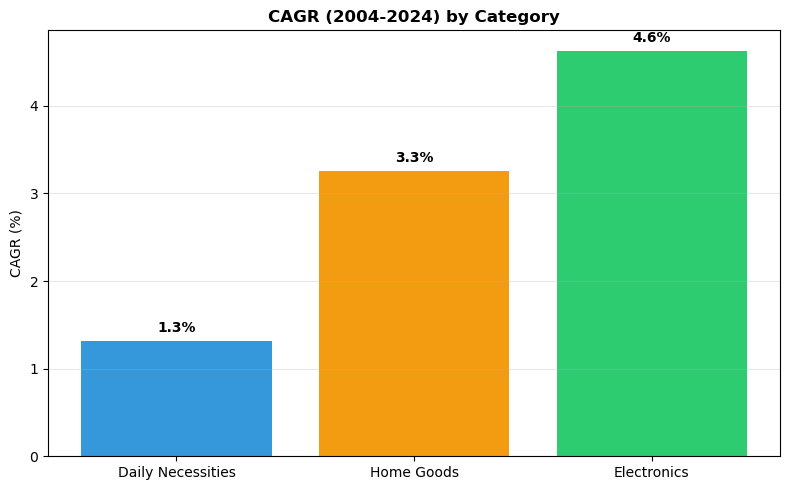

Electronics has the highest CAGR, showing the strongest long‑term growth. Home goods and daily necessities grow at lower but stable rates.


In [13]:
def calculate_cagr(start, end, periods):
    return (end / start) ** (1 / periods) - 1

cagr_nec = calculate_cagr(y_nec[0], y_nec[-1], 20)
cagr_home = calculate_cagr(y_home[0], y_home[-1], 20)
cagr_ele = calculate_cagr(y_ele[0], y_ele[-1], 20)

categories = ["Daily Necessities", "Home Goods", "Electronics"]
cagr_values = [cagr_nec*100, cagr_home*100, cagr_ele*100]
colors = ["#3498db", "#f39c12", "#2ecc71"]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, cagr_values, color=colors)

for bar, val in zip(bars, cagr_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f"{val:.1f}%",
             ha="center", fontweight="bold")

plt.title("CAGR (2004-2024) by Category", fontweight="bold")
plt.ylabel("CAGR (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Electronics has the highest CAGR, showing the strongest long‑term growth. Home goods and daily necessities grow at lower but stable rates.")